<a href="https://colab.research.google.com/github/MonsterDeveloper/real-time-trash-sorting/blob/main/Colab%20Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Dataset Preparation: TrashNet -> German Bins

Remaps the TrashNet dataset (6 material classes) to 4 German waste-bin
categories (Blaue Tonne, Glas, Wertstofftonne, Restmüll) and produces
a reproducible train/val/test split.

In [ ]:
!git clone https://github.com/garythung/trashnet.git
!unzip -q trashnet/data/dataset-resized.zip -d trashnet/data/

Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 6), reused 1 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 31.65 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [ ]:
from pathlib import Path

SOURCE = Path("trashnet/data/dataset-resized")

for class_dir in sorted(SOURCE.iterdir()):
    if class_dir.is_dir():
        count = len(list(class_dir.glob("*.jpg")))
        print(f"{class_dir.name}: {count}")

cardboard: 403
glass: 501
metal: 410
paper: 594
plastic: 482
trash: 137


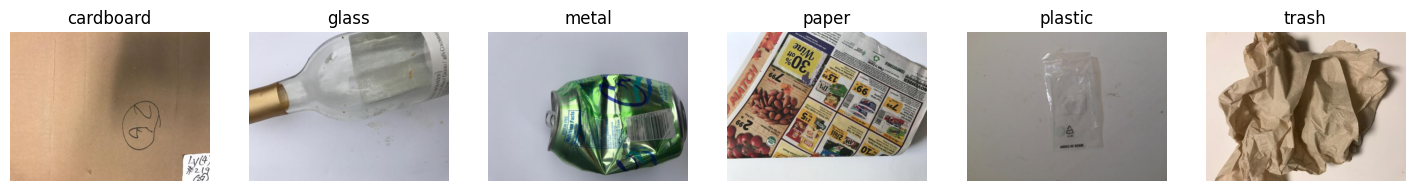

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]
fig, axes = plt.subplots(1, 6, figsize=(18, 3))

for ax, cls in zip(axes, classes):
    img_path = random.choice(list((SOURCE / cls).glob("*.jpg")))
    ax.imshow(Image.open(img_path))
    ax.set_title(cls)
    ax.axis("off")

plt.show()

In [ ]:
corrupted = []
for img_path in SOURCE.rglob("*.jpg"):
    try:
        with Image.open(img_path) as img:
            img.verify()
    except Exception as e:
        corrupted.append((img_path, e))

print(f"Corrupted files: {len(corrupted)}")

Corrupted files: 0


In [ ]:
import shutil

DEST = Path("trashnet-de")

BIN_MAPPING = {
    "cardboard": "blaue_tonne",
    "paper":     "blaue_tonne",
    "glass":     "glas",
    "metal":     "wertstofftonne",
    "plastic":   "wertstofftonne",
    "trash":     "restmuell",
}

for src_class, de_class in BIN_MAPPING.items():
    dst_dir = DEST / de_class
    dst_dir.mkdir(parents=True, exist_ok=True)
    for img in (SOURCE / src_class).glob("*.jpg"):
        shutil.copy(img, dst_dir / f"{src_class}_{img.name}")

for de_class in sorted(set(BIN_MAPPING.values())):
    count = len(list((DEST / de_class).glob("*.jpg")))
    print(f"{de_class}: {count}")

blaue_tonne: 997
glas: 501
restmuell: 137
wertstofftonne: 892


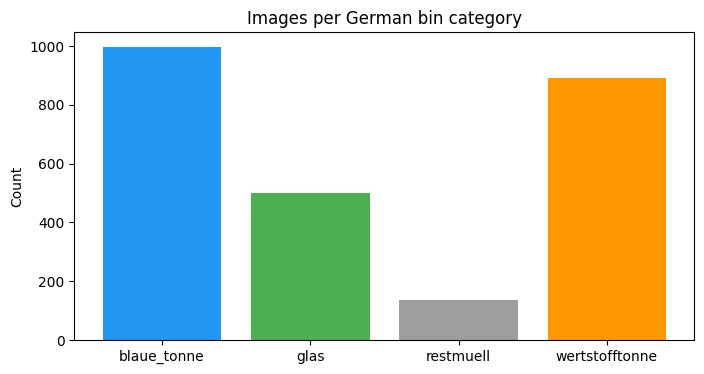

{'blaue_tonne': 0.6337, 'glas': 1.261, 'restmuell': 4.6113, 'wertstofftonne': 0.7082}


In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

de_classes = sorted(set(BIN_MAPPING.values()))
counts = [len(list((DEST / c).glob("*.jpg"))) for c in de_classes]

# Bar chart of the imbalance
plt.figure(figsize=(8, 4))
plt.bar(de_classes, counts, color=["#2196F3", "#4CAF50", "#9E9E9E", "#FF9800"])
plt.title("Images per German bin category")
plt.ylabel("Count")
plt.show()

# Compute balanced class weights for Andrei to use during training
labels = []
for de_class, count in zip(de_classes, counts):
    labels.extend([de_class] * count)

weights = compute_class_weight("balanced", classes=np.array(de_classes), y=np.array(labels))
class_weights = dict(zip(de_classes, weights.round(4).tolist()))

with open("class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

print(class_weights)

In [ ]:
from sklearn.model_selection import train_test_split
import random

random.seed(42)
splits = {"train": [], "val": [], "test": []}

for de_class in de_classes:
    images = sorted([img.name for img in (DEST / de_class).glob("*.jpg")])
    train, temp = train_test_split(images, test_size=0.3, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    for split_name, files in [("train", train), ("val", val), ("test", test)]:
        splits[split_name].extend([f"{de_class}/{f}" for f in files])

with open("splits.json", "w") as f:
    json.dump(splits, f, indent=2)

for name, files in splits.items():
    print(f"{name}: {len(files)} images")

train: 1766 images
val: 380 images
test: 381 images


In [ ]:
from google.colab import files
files.download("splits.json")
files.download("class_weights.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Summary

- Remapped TrashNet's 6 material classes to 4 German bin categories:
  cardboard + paper → Blaue Tonne, glass → Glas, metal + plastic →
  Wertstofftonne, trash → Restmüll.
- Total: 2527 images. Blaue Tonne 997, Glas 501, Wertstofftonne 892,
  Restmüll 137.
- Class imbalance is significant (Restmüll has only 137 images). Balanced
  class weights computed and saved to class_weights.json.
- Reproducible 70/15/15 train/val/test split (seed=42), stratified per
  class, saved to splits.json.
- Known limitation: TrashNet is US-collected (Stanford, 2016) and may not
  generalize to German product packaging — to be evaluated.

# 2. Model Training

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Loading (from Step 1)

In [3]:
# 1. Download TrashNet

from pathlib import Path
import json
import shutil
import os

%cd /content

if not Path("trashnet").exists():
    !git clone https://github.com/garythung/trashnet.git

if not Path("trashnet/data/dataset-resized").exists():
    !unzip -q trashnet/data/dataset-resized.zip -d trashnet/data/

SOURCE = Path("/content/trashnet/data/dataset-resized")
DEST = Path("/content/trashnet-de")

print("Source exists:", SOURCE.exists())
print("Classes:", sorted([p.name for p in SOURCE.iterdir() if p.is_dir()]))

# 2. Re-create remapped

BIN_MAPPING = {
    "cardboard": "blaue_tonne",
    "paper": "blaue_tonne",
    "glass": "glas",
    "metal": "wertstofftonne",
    "plastic": "wertstofftonne",
    "trash": "restmuell",
}

# Rebuild the remapped folder from scratch so repeated notebook runs are clean.
if DEST.exists():
    shutil.rmtree(DEST)

for src_class, de_class in BIN_MAPPING.items():
    dst_dir = DEST / de_class
    dst_dir.mkdir(parents=True, exist_ok=True)

    for img in sorted((SOURCE / src_class).glob("*.jpg")):
        # Prefix the original TrashNet class to avoid filename collisions.
        shutil.copy(img, dst_dir / f"{src_class}_{img.name}")

for class_dir in sorted(DEST.iterdir()):
    print(class_dir.name, len(list(class_dir.glob("*.jpg"))))

# 3. Load prepped class weights and splits

DATA_META = Path("/content/real-time-trash-sorting/data")

if not (DATA_META / "splits.json").exists() or not (DATA_META / "class_weights.json").exists():
    !git clone https://github.com/MonsterDeveloper/real-time-trash-sorting

    DATA_META.mkdir(exist_ok=True)

with open(DATA_META / "splits.json", "r") as f:
    splits = json.load(f)

with open(DATA_META / "class_weights.json", "r") as f:
    class_weights_by_name = json.load(f)

class_names = sorted(class_weights_by_name.keys())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

# Keras expects class_weight keys to be integer class indices, not class names.
class_weight = {
    class_to_idx[name]: float(weight)
    for name, weight in class_weights_by_name.items()
}

print("Class order:", class_names)
print("Class indices:", class_to_idx)
print("Class weights:", class_weight)

for split_name, files in splits.items():
    print(f"{split_name}: {len(files)} images")

# 4. Build tf.data datasets from split files

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(class_names)

def make_paths_and_labels(split_name):
    paths = []
    labels = []

    for rel_path in splits[split_name]:
        class_name = rel_path.split("/")[0]
        full_path = DEST / rel_path

        paths.append(str(full_path))
        labels.append(class_to_idx[class_name])

    return paths, labels

def load_image(path, label):
    # Read JPEG from disk.
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)

    # EfficientNetV2B0 expects 224x224 input.
    image = tf.image.resize(image, IMG_SIZE)

    # Keep values in 0..255 because we will use EfficientNetV2B0
    # with include_preprocessing=True, so the model handles scaling.
    image = tf.cast(image, tf.float32)

    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

def make_dataset(split_name, shuffle=False):
    paths, labels = make_paths_and_labels(split_name)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset("train", shuffle=True)
val_ds = make_dataset("val", shuffle=False)
test_ds = make_dataset("test", shuffle=False)

for images, labels in train_ds.take(1):
    print("Image batch:", images.shape)
    print("Label batch:", labels.shape)

/content
Cloning into 'trashnet'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 45 (delta 6), reused 1 (delta 0), pack-reused 33 (from 1)
Receiving objects: 100% (45/45), 40.64 MiB | 23.83 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Source exists: True
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
blaue_tonne 997
glas 501
restmuell 137
wertstofftonne 892
Cloning into 'real-time-trash-sorting'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 26 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 279.64 KiB | 1.59 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Class order: ['blaue_tonne', 'glas', 'restmuell', 'wertstofftonne']
Class indices: {'blaue_tonne': 0, 'glas': 1, 'restmuell': 2, 'wertstofftonne': 3}
Class weigh

## Training

### First Phase

- load ImageNet weights
- freeze the EfficientNet base
- train only the small classification head

In [4]:
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2B0

tf.keras.utils.set_random_seed(42)

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.10),
        layers.RandomContrast(0.10),
    ],
    name="data_augmentation",
)

base_model = EfficientNetV2B0(
    weights="imagenet",
    include_top=False,
    include_preprocessing=True,
    input_shape=(224, 224, 3),
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,924,436 (22.60 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

### Second phase
Train the frozen-base model

In [5]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        "efficientnetv2b0_trashnet_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 31s 183ms/step - accuracy: 0.6133 - loss: 0.9678 - val_accuracy: 0.7921 - val_loss: 0.5795 - learning_rate: 0.0010
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - accuracy: 0.7871 - loss: 0.5999 - val_accuracy: 0.8526 - val_loss: 0.4359 - learning_rate: 0.0010
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.8069 - loss: 0.5184 - val_accuracy: 0.8447 - val_loss: 0.4234 - learning_rate: 0.0010
Epoch 4/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 87ms/step - accuracy: 0.8307 - loss: 0.4533 - val_accuracy: 0.8447 - val_loss: 0.3989 - learning_rate: 0.0010
Epoch 5/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 101ms/step - accuracy: 0.8499 - loss: 0.4176 - val_accuracy: 0.8526 - val_loss: 0.3900 - learning_rate: 0.0010
Epoch 6/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.8420 - loss: 0.3964 - val_accuracy: 0.8684 - val_loss: 0.3571 - learning_rate: 0.0010
Epoch 7/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.8550 - loss: 0.3723 - val_

### Third phase
Fine-tune the last EfficientNetV2B0 layers
- unfreeze only the last part of the base model
- keep BatchNorm layers frozen for stable fine-tuning
- use a much lower learning rate

In [6]:
base_model.trainable = True

# Freeze most of the backbone and only fine-tune the last layers.
# You can adjust this number. 40 is a conservative starting point for B0.
fine_tune_at = len(base_model.layers) - 40

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNorm statistics are fragile on small datasets, so keep them frozen.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Total base layers:", len(base_model.layers))
print("Fine-tuning from layer:", fine_tune_at)
print("Trainable layers:", sum(layer.trainable for layer in model.layers))

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=callbacks,
)

Total base layers: 270
Fine-tuning from layer: 230
Trainable layers: 6
Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 168ms/step - accuracy: 0.8975 - loss: 0.2771 - val_accuracy: 0.8868 - val_loss: 0.2835 - learning_rate: 1.0000e-05
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 22s 169ms/step - accuracy: 0.9105 - loss: 0.2526 - val_accuracy: 0.8895 - val_loss: 0.2791 - learning_rate: 1.0000e-05
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 18s 135ms/step - accuracy: 0.8998 - loss: 0.2617 - val_accuracy: 0.8947 - val_loss: 0.2763 - learning_rate: 1.0000e-05
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.9077 - loss: 0.2512 - val_accuracy: 0.8947 - val_loss: 0.2760 - learning_rate: 1.0000e-05
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 11s 139ms/step - accuracy: 0.9083 - loss: 0.2434 - val_accuracy: 0.8974 - val_loss: 0.2708 - learning_rate: 1.0000e-05
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.9077 - loss: 0.2412 - val_accuracy: 0.8947 - val_loss: 0.2727 - learning_rate: 

## Quick Eval & Save
Evaluate on test dataset that was not used for training & validation.




In [7]:
best_model = tf.keras.models.load_model("efficientnetv2b0_trashnet_best.keras")

test_loss, test_acc = best_model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 115ms/step - accuracy: 0.8976 - loss: 0.2911
Test loss: 0.2911
Test accuracy: 0.8976


In [8]:
# Save for later
model_filename = "efficientnetv2b0_trashnet_de.keras"
best_model.save(model_filename)
print(f"Saved model to {model_filename}")

Saved model to efficientnetv2b0_trashnet_de.keras
